<a href="https://colab.research.google.com/github/MarinaAljout/Bioinfo-Projects-Portfolio/blob/Python-Projects/Clinical_Dosage_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Initializing Drug Database ---
  Drug_name  safe_dose_per_kg  max_daily_dose
Paracetamol                15            4000
  Ibuprofen                10            1200
Amoxicillin                20            1500
--------------------------------------------------
File has been saved successfuly!
--------------------------------------------------
--- Welcome to Clinical Dose Analyzer ---
Enter drug name:Paracetamol
Enter patient weight (kg):50
Result for Paracetamol:
Calculated Dose: 750.0 mg
Dose is safe.
--------------------------------------------------
--- Drug-Drug Interaction Checker ---
Enter first drug:Paracetamol
Enter second drug:aspirin
No major interaction found between Paracetamol and Aspirin.
No major interaction found between Paracetamol and Aspirin.
--------------------------------------------------
Drugs with Max Daily Dose less than 2000 mg:
   Drug_name  safe_dose_per_kg  max_daily_dose
  Ibuprofen                10            1200
Amoxicillin                20 

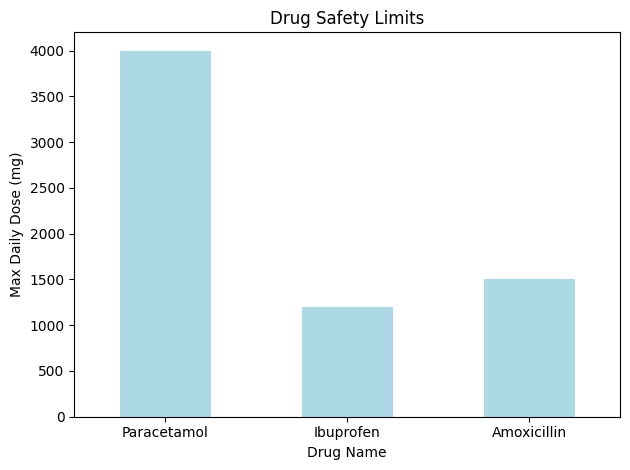

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ===================================
# 1. DATA LOADING & INITIALIZATION
# ===================================

drugs_data = {
    "Paracetamol" : {"safe_dose_per_kg": 15, "max_daily_dose": 4000},
    "Ibuprofen" : {"safe_dose_per_kg": 10, "max_daily_dose": 1200},
    "Amoxicillin" : {"safe_dose_per_kg": 20, "max_daily_dose": 1500}
}

df_drugs = pd.DataFrame([{"Drug_name": k, **v} for k, v in drugs_data.items()])

print("--- Initializing Drug Database ---")
print(df_drugs.to_string(index=False))
print("-" * 50)

excel_file = "Clinical_Drug_Database.xlsx"
try:
  df_drugs.to_excel(excel_file, index=False)
  print("File has been saved successfuly!")
except Exception as e:
  print(f"Error saving the file! Reason: {e}")
print("-" * 50)

# ===================================
# 2. Clinical Dose Analyzer & Input Validation
# ===================================

print("--- Welcome to Clinical Dose Analyzer ---")
selected_drug = input("Enter drug name:").strip().capitalize()
if selected_drug in df_drugs["Drug_name"].values:
  try:
    weight_input = input("Enter patient weight (kg):").strip()
    weight = float(weight_input)
    if weight <= 0:
      print("Error: Weight must be a positive number!")
    else:
      drug_info = df_drugs[df_drugs["Drug_name"] == selected_drug].iloc[0]
      final_dose = drug_info["safe_dose_per_kg"] * weight
      max_limit = drug_info["max_daily_dose"]
    print(f"Result for {selected_drug}:")
    print(f"Calculated Dose: {final_dose} mg")

    if final_dose > max_limit:
      print(f"WARNING: Exceeds Max limit ({max_limit} mg)!")
    else:
      print("Dose is safe.")
  except ValueError:
    print("Error: Please Enter a valid numeric value for weight.")
else:
  print("Drug not found in database.")
print("-" * 50)

# ===================================
# 3. Drug-Drug Interaction Checker
# ===================================

print("--- Drug-Drug Interaction Checker ---")
interactions = [
    {"Ibuprofen" , "Aspirin"},
    {"Amoxicillin" , "Methotrexate"}
]
drug1 = input("Enter first drug:").strip().capitalize()
drug2 = input("Enter second drug:").strip().capitalize()
current_combination = {drug1, drug2}

for interact in interactions:
  if interact == current_combination:
    print(f"ALERT: There is a known interaction between {drug1} and {drug2}!")
    break
  else:
    print(f"No major interaction found between {drug1} and {drug2}.")
print("-" * 50)

# ===================================
# 4. Data Visualization
# ===================================

low_dose_drugs = df_drugs[df_drugs["max_daily_dose"] < 2000]
print("Drugs with Max Daily Dose less than 2000 mg:\n" , low_dose_drugs.to_string(index=False))

df_drugs.plot(kind='bar' , x = 'Drug_name' , y = 'max_daily_dose' , color = 'lightblue' , legend = False)
plt.title("Drug Safety Limits")
plt.xlabel("Drug Name")
plt.ylabel("Max Daily Dose (mg)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()